In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd



Loading ROC data from: /zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_1/cv_detailed.json


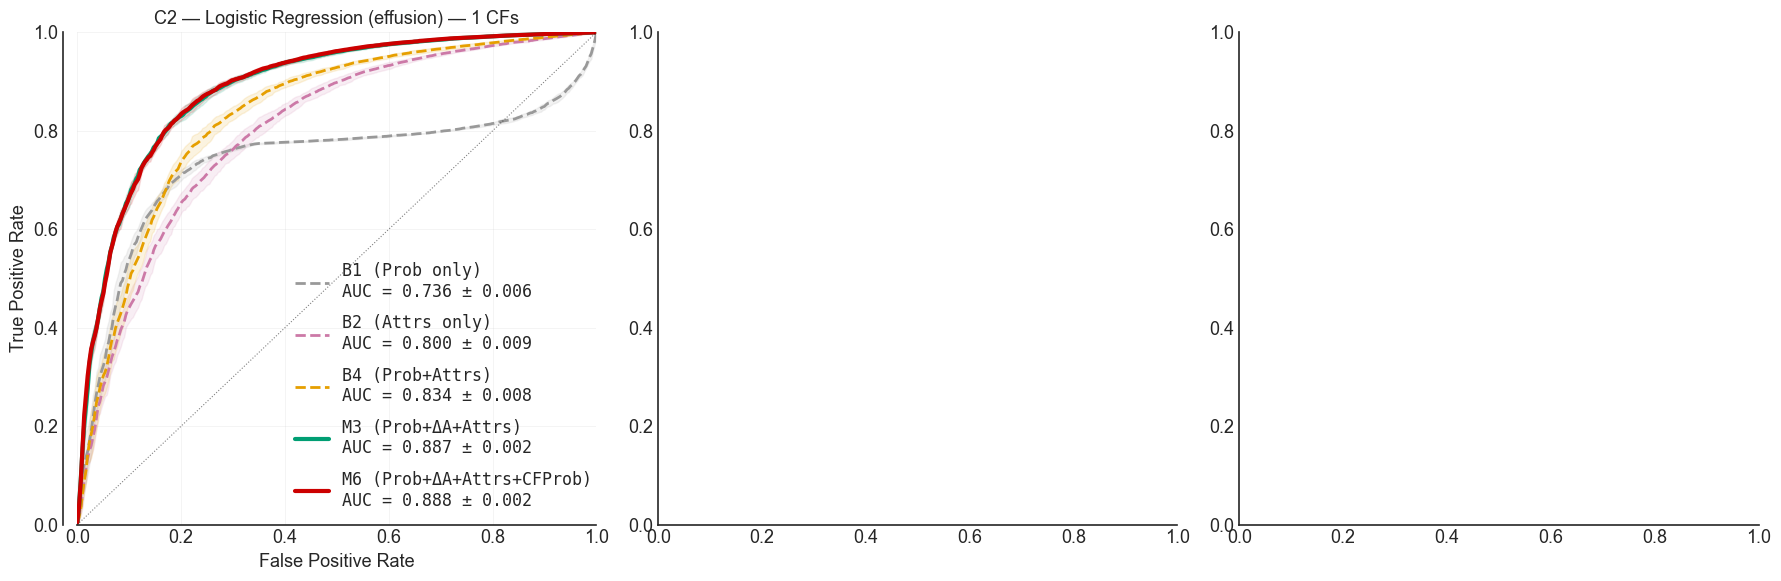

Saved → ./roc_all_models_1.png


In [12]:

# ── Config ────────────────────────────────────────────────────────────────────
DISEASE = 'effusion'  # or 'effusion'
CF_COUNT   = 1
ROC_PATH   = f'/zhome/d0/a/221493/thesis/results/C2_custom/{DISEASE}/cv_results/cf_{CF_COUNT}/cv_detailed.json'
print(f"Loading ROC data from: {ROC_PATH}")
OUTPUT_DIR = '.'

MODELS_TO_PLOT = ['LR']
CONFIGS_TO_SHOW = {
    'LR':  ['B1', 'B2', 'B4', 'M3', 'M6'],
    'RF':  ['B1', 'B2', 'B4', 'M3', 'M6'],
    'MLP': ['B1', 'B2', 'B4', 'M3', 'M6'],
}
COLORS = {
    'B1': '#999999', 'B2': '#CC79A7', 'B3': '#F0E442',
    'B4': '#E69F00', 'B5': '#D55E00', 'M1': '#56B4E9',
    'M2': '#0072B2', 'M3': '#009E73', 'M4': '#9370DB',
    'M5': '#2D2D2D', 'M6': '#CC0000',
}
LINESTYLES = {k: '--' if k.startswith('B') else '-' for k in COLORS}
LINEWIDTHS = {k:  2   if k.startswith('B') else 3   for k in COLORS}
LABELS = {
    'B1': 'B1 (Prob only)',        'B2': 'B2 (Attrs only)',
    'B3': 'B3 (Embeddings only)',  'B4': 'B4 (Prob+Attrs)',
    'B5': 'B5 (Prob+Emb)',         'M1': 'M1 (ΔA only)',
    'M2': 'M2 (Prob+ΔA)',          'M3': 'M3 (Prob+ΔA+Attrs)',
    'M4': 'M4 (Prob+ΔA+Emb)',      'M5': 'M5 (Prob+ΔA+Attrs+Emb)',
    'M6': 'M6 (Prob+ΔA+Attrs+CFProb)',
}
MODEL_NAMES = {'LR': 'Logistic Regression', 'RF': 'Random Forest', 'MLP': 'Multilayer Perceptron'}

# ── Load and average ROC across folds ─────────────────────────────────────────
with open(ROC_PATH) as f:
    raw = json.load(f)

common_fpr = np.linspace(0, 1, 300)
roc_data = {}
for model in MODELS_TO_PLOT:
    roc_data[model] = {}
    for config in CONFIGS_TO_SHOW[model]:
        folds = raw[model][config]
        mean_auc = np.mean([f['auc'] for f in folds])
        tprs = [np.interp(common_fpr, f['fpr'], f['tpr']) for f in folds]
        roc_data[model][config] = {
            'fpr': common_fpr,
            'tpr': np.mean(tprs, axis=0),
            'std': np.std(tprs, axis=0),   # <-- add this
            'auc': mean_auc,
            'auc_std': np.std([f['auc'] for f in folds])  # <-- and this for the label
        }

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 13,
    'axes.titlesize': 13, 'axes.labelsize': 13,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.2, 'grid.alpha': 0.3,
    'grid.linewidth': 0.6, 'lines.linewidth': 1.8,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, model_name in zip(axes, MODELS_TO_PLOT):
    for config in CONFIGS_TO_SHOW[model_name]:
        d = roc_data[model_name][config]
        ax.plot(d['fpr'], d['tpr'],
                color=COLORS[config], lw=LINEWIDTHS[config], ls=LINESTYLES[config],
                label=f"{LABELS[config]}\nAUC = {d['auc']:.3f} ± {d['auc_std']:.3f}")
        ax.fill_between(d['fpr'],
                        d['tpr'] - d['std'],
                        d['tpr'] + d['std'],
                        color=COLORS[config], alpha=0.12)  # adjust alpha to taste
    ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'C2 — {MODEL_NAMES[model_name]} ({DISEASE}) — {CF_COUNT} CFs')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.spines['left'].set_position(('outward', 10))
    ax.legend(loc='lower right', bbox_to_anchor=(1.02, 0.0),
              prop={'family': 'monospace', 'size': 12},
              framealpha=0.95, edgecolor='#cccccc', handlelength=2, labelspacing=0.8)
    ax.grid(alpha=0.30, linewidth=0.5)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, f'roc_all_models_{CF_COUNT}.png')
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(out_path, dpi=600, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

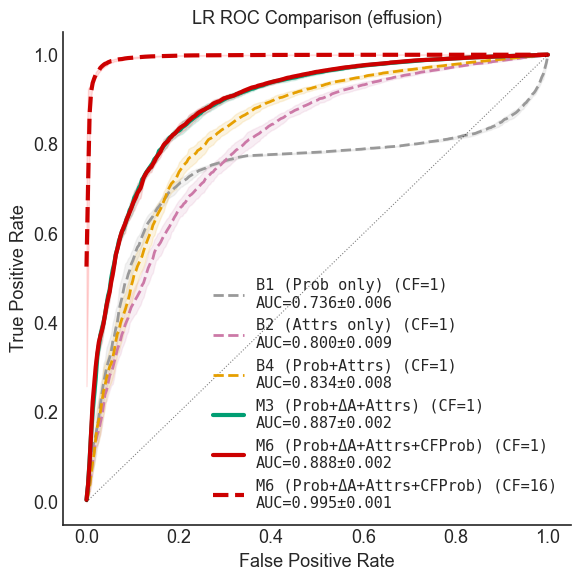

In [26]:
# Load M6 from cf=16
with open(f'/zhome/d0/a/221493/thesis/results/C2_custom/{DISEASE}/cv_results/cf_16/cv_detailed.json') as f:
    raw_cf16 = json.load(f)

folds_cf16 = raw_cf16['LR']['M6']
mean_auc_cf16 = np.mean([f['auc'] for f in folds_cf16])
tprs_cf16 = [np.interp(common_fpr, f['fpr'], f['tpr']) for f in folds_cf16]

m6_cf16 = {
    'fpr': common_fpr,
    'tpr': np.mean(tprs_cf16, axis=0),
    'std': np.std(tprs_cf16, axis=0),
    'auc': mean_auc_cf16,
    'auc_std': np.std([f['auc'] for f in folds_cf16])
}

fig, ax = plt.subplots(figsize=(6, 6))

configs = ['B1', 'B2', 'B4', 'M3', 'M6']

for config in configs:
    d = roc_data['LR'][config]

    ax.plot(
        d['fpr'], d['tpr'],
        color=COLORS[config],
        lw=LINEWIDTHS[config],
        ls=LINESTYLES[config],
        label=f"{LABELS[config]} (CF=1)\nAUC={d['auc']:.3f}±{d['auc_std']:.3f}"
    )

    ax.fill_between(
        d['fpr'],
        d['tpr'] - d['std'],
        d['tpr'] + d['std'],
        color=COLORS[config],
        alpha=0.12
    )

# Add M6 CF=16
ax.plot(
    m6_cf16['fpr'],
    m6_cf16['tpr'],
    color=COLORS[config],
    lw=3,
    ls='--',
    label=f"{LABELS[config]} (CF=16)\nAUC={m6_cf16['auc']:.3f}±{m6_cf16['auc_std']:.3f}"
)

ax.fill_between(
    m6_cf16['fpr'],
    m6_cf16['tpr'] - m6_cf16['std'],
    m6_cf16['tpr'] + m6_cf16['std'],
    color='red',
    alpha=0.12
)

ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'LR ROC Comparison ({DISEASE})')

ax.legend(
    loc='lower right',
    prop={'family': 'monospace', 'size': 11}
)

plt.tight_layout()
plt.show()

---


# Comparing with (SC-CE) Counterfactual Distance as a quality score for predictions

In [3]:
# Load detailed json results for SC-CE Counterfactual Distance
SC_CE_PATH = f'/zhome/d0/a/221493/thesis/results/C2_custom/{DISEASE}/cv_results/cf_{CF_COUNT}/sc_ce_detailed.json'

with open(SC_CE_PATH) as f:
    sc_ce = json.load(f)
    
print(f"Loaded SC-CE Counterfactual Distance data from: {SC_CE_PATH}")
print("SC-CE Counterfactual Distance data keys:", sc_ce.keys())

Loaded SC-CE Counterfactual Distance data from: /zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_1/sc_ce_detailed.json
SC-CE Counterfactual Distance data keys: dict_keys(['l1', 'l2'])


In [4]:
sc_ce['l1']

[{'auc': 0.4829349588923859,
  'fpr': [0.0,
   0.0,
   0.0,
   0.0013386880856760374,
   0.0013386880856760374,
   0.002677376171352075,
   0.002677376171352075,
   0.004016064257028112,
   0.004016064257028112,
   0.00535475234270415,
   0.00535475234270415,
   0.006693440428380187,
   0.006693440428380187,
   0.008032128514056224,
   0.008032128514056224,
   0.009370816599732263,
   0.009370816599732263,
   0.0107095046854083,
   0.0107095046854083,
   0.012048192771084338,
   0.012048192771084338,
   0.013386880856760375,
   0.013386880856760375,
   0.014725568942436412,
   0.014725568942436412,
   0.01606425702811245,
   0.01606425702811245,
   0.01740294511378849,
   0.01740294511378849,
   0.018741633199464525,
   0.018741633199464525,
   0.020080321285140562,
   0.020080321285140562,
   0.0214190093708166,
   0.0214190093708166,
   0.022757697456492636,
   0.022757697456492636,
   0.024096385542168676,
   0.024096385542168676,
   0.025435073627844713,
   0.025435073627844713,
  

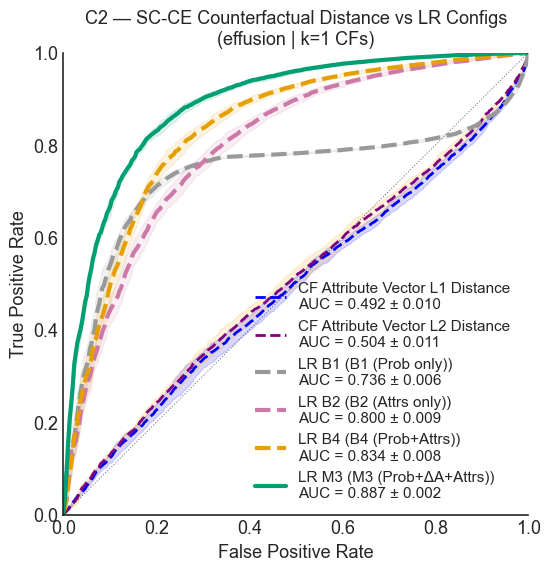

In [5]:
import numpy as np
import matplotlib.pyplot as plt

folds_l1 = sc_ce['l1']
folds_l2 = sc_ce['l2']

# Common FPR grid
common_fpr = np.linspace(0, 1, 300)

# Interpolate all TPRs onto same grid
tprs_l1 = [
    np.interp(common_fpr, f['fpr'], f['tpr'])
    for f in folds_l1
]
tprs_l2 = [
    np.interp(common_fpr, f['fpr'], f['tpr'])
    for f in folds_l2
]

# Mean + std
mean_tpr_l1 = np.mean(tprs_l1, axis=0)
std_tpr_l1  = np.std(tprs_l1, axis=0)
mean_tpr_l2 = np.mean(tprs_l2, axis=0)
std_tpr_l2  = np.std(tprs_l2, axis=0)

# Mean + std AUC
mean_auc_l1 = np.mean([f['auc'] for f in folds_l1])
std_auc_l1  = np.std([f['auc'] for f in folds_l1])
mean_auc_l2 = np.mean([f['auc'] for f in folds_l2])
std_auc_l2  = np.std([f['auc'] for f in folds_l2])

# Plot
plt.figure(figsize=(6,6))

plt.plot(
    common_fpr,
    mean_tpr_l1,
    color='blue',
    linestyle='--',
    lw=2,
    label=f"CF Attribute Vector L1 Distance \nAUC = {mean_auc_l1:.3f} ± {std_auc_l1:.3f}"
)
plt.plot(
    common_fpr,
    mean_tpr_l2,
    color='purple',
    linestyle='--',
    lw=2,
    label=f"CF Attribute Vector L2 Distance \nAUC = {mean_auc_l2:.3f} ± {std_auc_l2:.3f}"
)   

plt.fill_between(
    common_fpr,
    mean_tpr_l1 - std_tpr_l1,
    mean_tpr_l1 + std_tpr_l1,
    color='blue',
    alpha=0.15
)

plt.fill_between(
    common_fpr,
    mean_tpr_l2 - std_tpr_l2,
    mean_tpr_l2 + std_tpr_l2,
    color='orange',
    alpha=0.15
)

comparisons = ['B1','B2', 'B4', 'M3']  # <-- specify which configs to compare
for comp in comparisons:
    d_lr = roc_data['LR'][comp]

    plt.plot(
        d_lr['fpr'],
        d_lr['tpr'],
        color=COLORS[comp],
        lw=3,
        linestyle='-' if comp.startswith('M') else '--',
        label=f"LR {comp} ({LABELS[comp]}) \nAUC = {d_lr['auc']:.3f} ± {d_lr['auc_std']:.3f}"
    )
    plt.fill_between(
        d_lr['fpr'],
        d_lr['tpr'] - d_lr['std'],
        d_lr['tpr'] + d_lr['std'],
        color=COLORS[comp],
        alpha=0.12
    )

plt.plot([0,1], [0,1], 'k:', lw=0.8, alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.title(f"C2 — SC-CE Counterfactual Distance vs LR Configs\n({DISEASE} | k={CF_COUNT} CFs)")

plt.xlim(0,1)
plt.ylim(0,1)

plt.show()

# Comparing MATCHED m6 with unmatched m6

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
CF_COUNT = 1

matched_json = "/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_1/cv_detailed.json"
unmatched_json = "/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results_unmatched/cf_1/cv_detailed.json"

with open(matched_json) as f:
    matched_data = json.load(f)\

with open(unmatched_json) as f:
    unmatched_data = json.load(f)

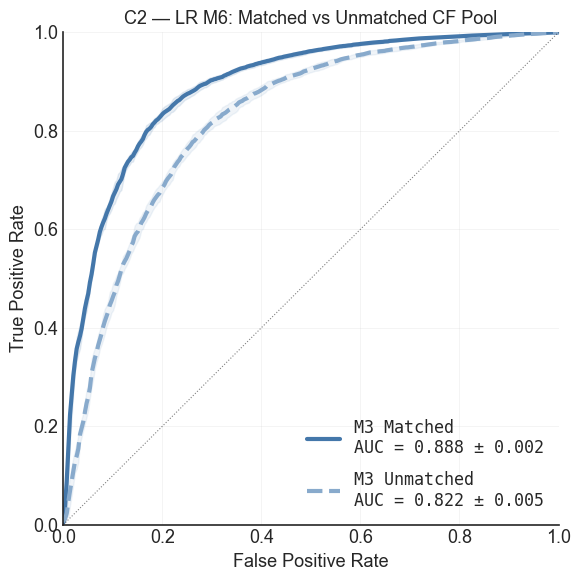

In [4]:
# ── Compare matched vs unmatched M6 ───────────────────────────────────────────
model_type = 'LR'  # change to 'LR' or 'RF' if needed
config     = 'M6'

common_fpr = np.linspace(0, 1, 300)

def get_mean_roc(data, model, cfg):
    folds = data[model][cfg]
    tprs  = [np.interp(common_fpr, f['fpr'], f['tpr']) for f in folds]
    return {
        'tpr':     np.mean(tprs, axis=0),
        'std':     np.std(tprs,  axis=0),
        'auc':     np.mean([f['auc'] for f in folds]),
        'auc_std': np.std( [f['auc'] for f in folds]),
    }

matched   = get_mean_roc(matched_data,   model_type, config)
unmatched = get_mean_roc(unmatched_data, model_type, config)

fig, ax = plt.subplots(figsize=(6, 6))

for d, label, color, ls in [
    (matched,   'M3 Matched',   '#4477AA', '-'),
    (unmatched, 'M3 Unmatched', '#88AACC', '--'),
]:
    ax.plot(common_fpr, d['tpr'], color=color, lw=3, ls=ls,
            label=f"{label}\nAUC = {d['auc']:.3f} ± {d['auc_std']:.3f}")
    ax.fill_between(common_fpr,
                    d['tpr'] - d['std'],
                    d['tpr'] + d['std'],
                    color=color, alpha=0.12)

ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'C2 — {model_type} {config}: Matched vs Unmatched CF Pool')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='lower right', prop={'family': 'monospace', 'size': 12},
          framealpha=0.95, edgecolor='#cccccc', handlelength=2, labelspacing=0.8)
ax.grid(alpha=0.30, linewidth=0.5)

plt.tight_layout()
plt.show()

# Offsetting CF selection for disease absent cases

In [4]:
# NOW COMPARING THE EFFECT OF THE OFFSET
offset0_json = '/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/cv_detailed.json'
offset3_json = '/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/k_offset_3/cv_detailed.json'
offset_6_json = '/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/k_offset_6/cv_detailed.json' 
offset_9_json = '/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/k_offset_9/cv_detailed.json'
offset_12_json = '/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/k_offset_12/cv_detailed.json'


with open(offset0_json) as f:
    offset0_data = json.load(f)
    
with open(offset3_json) as f:
    offset3_data = json.load(f)
    
with open(offset_6_json) as f:
    offset6_data = json.load(f)
    
with open(offset_9_json) as f:
    offset9_data = json.load(f)
    
with open(offset_12_json) as f:
    offset12_data = json.load(f)
    

Offset 0 AUC: 0.9949859561310472 ± 0.001445224840198663
Offset 3 AUC: 0.9948584477782367 ± 0.0015411096122426953
Offset 6 AUC: 0.9950347124994952 ± 0.001439563708831909
Offset 9 AUC: 0.9954858686835649 ± 0.0014529640141127975
Offset 12 AUC: 0.9957881884367372 ± 0.001340609807932189


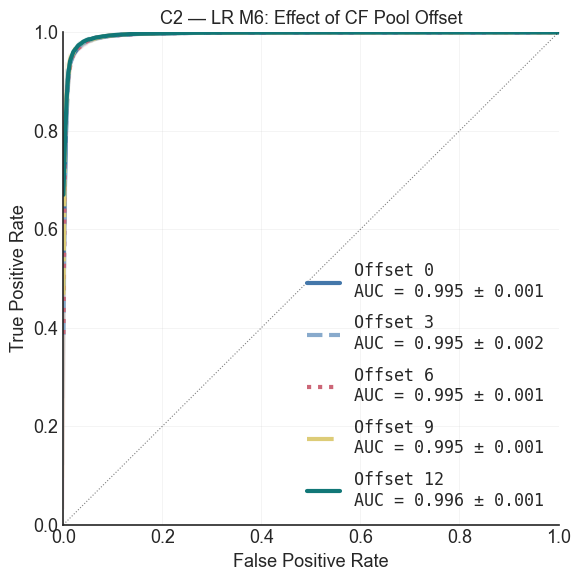

In [6]:
# Plot M6 across offset values
model_type = 'LR'
config     = 'M6'

def get_mean_roc(data, model, cfg):
    folds = data[model][cfg]
    tprs  = [np.interp(common_fpr, f['fpr'], f['tpr']) for f in folds]
    return {
        'tpr':     np.mean(tprs, axis=0),
        'std':     np.std(tprs,  axis=0),
        'auc':     np.mean([f['auc'] for f in folds]),
        'auc_std': np.std( [f['auc'] for f in folds]),
    }   
offset0 = get_mean_roc(offset0_data, model_type, config)
offset3 = get_mean_roc(offset3_data, model_type, config)
offset6 = get_mean_roc(offset6_data, model_type, config)
offset9 = get_mean_roc(offset9_data, model_type, config)
offset12 = get_mean_roc(offset12_data, model_type, config)

print("Offset 0 AUC:", offset0['auc'], "±", offset0['auc_std'])
print("Offset 3 AUC:", offset3['auc'], "±", offset3['auc_std'])
print("Offset 6 AUC:", offset6['auc'], "±", offset6['auc_std'])
print("Offset 9 AUC:", offset9['auc'], "±", offset9['auc_std'])
print("Offset 12 AUC:", offset12['auc'], "±", offset12['auc_std'])
fig, ax = plt.subplots(figsize=(6, 6))  

for d, label, color, ls in [
    (offset0, 'Offset 0', '#4477AA', '-'),
    (offset3, 'Offset 3', '#88AACC', '--'),
    (offset6, 'Offset 6', '#CC6677', ':'),
    (offset9, 'Offset 9', '#DDCC77', '-.'),
    (offset12, 'Offset 12', '#117777', '-'),
]:
    ax.plot(common_fpr, d['tpr'], color=color, lw=3, ls=ls,
            label=f"{label}\nAUC = {d['auc']:.3f} ± {d['auc_std']:.3f}")
    ax.fill_between(common_fpr,
                    d['tpr'] - d['std'],
                    d['tpr'] + d['std'],
                    color=color, alpha=0.12)
ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'C2 — {model_type} {config}: Effect of CF Pool Offset')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='lower right', prop={'family': 'monospace', 'size': 12},
          framealpha=0.95, edgecolor='#cccccc', handlelength=2, labelspacing=0.8)
ax.grid(alpha=0.30, linewidth=0.5)  
plt.tight_layout()
plt.show()

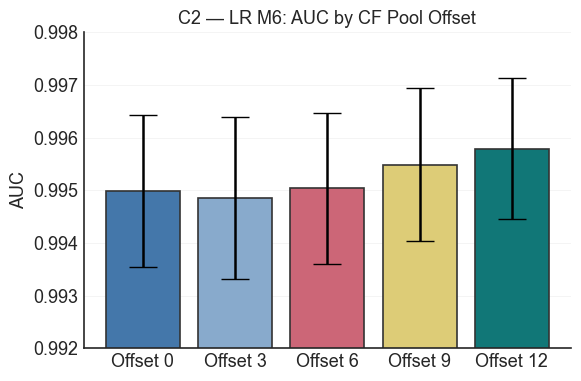

In [9]:
# Plot auc bar plot for the three offsets
offsets = ['Offset 0', 'Offset 3', 'Offset 6', 'Offset 9', 'Offset 12']
aucs = [offset0['auc'], offset3['auc'], offset6['auc'], offset9['auc'], offset12['auc']]
auc_stds = [offset0['auc_std'], offset3['auc_std'], offset6['auc_std'], offset9['auc_std'], offset12['auc_std']]
plt.figure(figsize=(6, 4))
bars = plt.bar(offsets, aucs, yerr=auc_stds, capsize=10, color=['#4477AA', '#88AACC', '#CC6677', '#DDCC77', '#117777'],
               edgecolor='#333333', linewidth=1.2)
plt.ylabel('AUC')
plt.title(f'C2 — {model_type} {config}: AUC by CF Pool Offset')
plt.ylim(0.992, 0.998)
plt.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

# ROC for CNN C2 Baseline

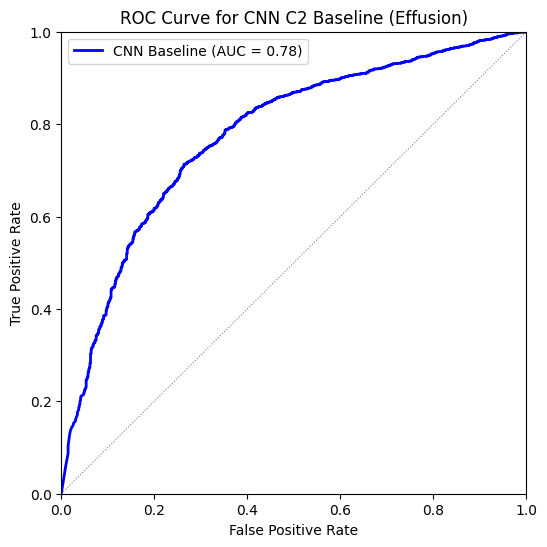

In [4]:
# Load the fpr and tpr files (npy)
from sklearn.metrics import auc


tpr = np.load('/zhome/d0/a/221493/thesis/results/C2_cnn_baseline/effusion/tpr.npy')
fpr = np.load('/zhome/d0/a/221493/thesis/results/C2_cnn_baseline/effusion/fpr.npy')
auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'CNN Baseline (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k:', lw=0.8, alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for CNN C2 Baseline (Effusion)")
# Legend
plt.xlim(0,1)
plt.ylim(0,1)
plt.legend()
plt.show()